In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


In [2]:
df = pd.read_csv("creditcard.csv")

print("Shape:", df.shape)

df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df["Class"].value_counts()


Class
0    284315
1       492
Name: count, dtype: int64

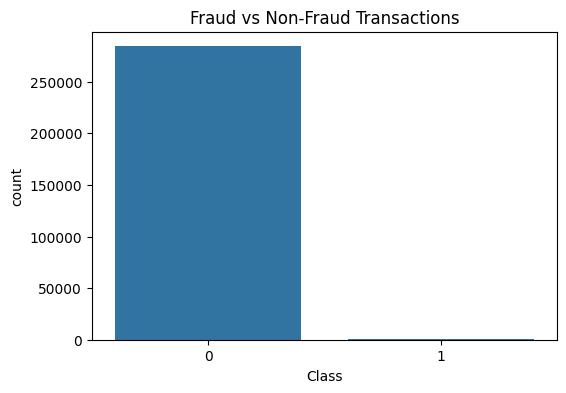

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Class",
    data=df
)

plt.title(
    "Fraud vs Non-Fraud Transactions"
)

plt.show()

In [5]:
fraud = df["Class"].value_counts()

print(
    "Non Fraud:",
    fraud[0]
)

print(
    "Fraud:",
    fraud[1]
)

print(
    "Fraud Percentage:",
    round(
        (fraud[1] / len(df)) * 100,
        4
    ),
    "%"
)

Non Fraud: 284315
Fraud: 492
Fraud Percentage: 0.1727 %


In [6]:
fraud_df = df[
    df["Class"] == 1
]

normal_df = df[
    df["Class"] == 0
]

In [7]:
fraud_df.shape

(492, 31)

In [8]:
normal_sample = normal_df.sample(
    n=492,
    random_state=42
)

In [9]:
balanced_df = pd.concat(

    [
        normal_sample,
        fraud_df
    ],

    axis=0

)

In [10]:
balanced_df["Class"].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

In [11]:
balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
)

In [12]:
balanced_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
42756,41233.0,-10.645800,5.918307,-11.671043,8.807369,-7.975501,-3.586806,-13.616797,6.428169,-7.368451,-12.888158,6.854953,-13.211695,1.035612,-13.778956,1.040448,-11.290328,-20.578022,-7.547824,3.118480,-0.046170,2.571970,0.206809,-1.667801,0.558419,-0.027898,0.354254,0.273329,-0.152908,0.00,1
1686,1308.0,-1.379848,0.536720,2.647870,1.408111,0.126442,0.986525,0.960251,-0.629717,1.729173,1.346832,-0.622458,0.516210,0.174168,-2.023273,-1.185043,-2.036791,0.653358,-1.294348,1.297445,0.464675,-0.666874,-0.343574,0.022138,0.093532,0.011293,-0.503395,-0.438189,-0.346731,43.80,0
111690,72327.0,-4.198735,0.194121,-3.917586,3.920748,-1.875486,-2.118933,-3.614445,1.687884,-2.189871,-4.684233,4.376907,-5.007441,-1.304745,-6.192475,1.002404,-3.316934,-6.188834,-1.040413,1.233044,1.003350,0.801312,-0.183001,-0.440387,0.292539,-0.144967,-0.251744,1.249414,-0.131525,238.90,1
128360,78685.0,-0.671155,1.183971,0.793623,-0.218410,0.357282,-0.023707,0.363563,0.463983,-0.704518,-0.774565,-1.133336,-0.066681,0.275205,0.500851,0.965494,0.149958,-0.210491,-0.474939,0.032152,-0.161347,-0.083474,-0.352537,-0.092199,-0.764804,-0.292712,0.185362,-0.028254,0.055953,1.30,0
20746,31244.0,1.087002,0.065459,0.485043,1.343874,-0.283361,0.002520,-0.076665,0.165384,0.151865,0.065573,1.192505,0.810490,-1.145781,0.455426,-0.710613,-0.543406,0.138989,-0.438125,-0.152541,-0.223027,-0.040723,0.016005,-0.048042,0.208209,0.571482,-0.340377,0.028643,0.007649,18.56,0


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X = balanced_df.drop(
    "Class",
    axis=1
)

y = balanced_df["Class"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

In [16]:
print(X_train.shape)

print(X_test.shape)

(787, 30)
(197, 30)


In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
model = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
predictions = model.predict(
    X_test
)

In [20]:
predictions = model.predict(
    X_test
)

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
accuracy = accuracy_score(

    y_test,

    predictions

)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.9289340101522843


In [23]:
from sklearn.metrics import classification_report

In [24]:
print(

    classification_report(

        y_test,

        predictions

    )

)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94       110
           1       1.00      0.84      0.91        87

    accuracy                           0.93       197
   macro avg       0.94      0.92      0.93       197
weighted avg       0.94      0.93      0.93       197



In [25]:
from sklearn.metrics import confusion_matrix

In [26]:
cm = confusion_matrix(

    y_test,

    predictions

)

print(cm)

[[110   0]
 [ 14  73]]


In [27]:
import joblib

In [28]:
import os

os.makedirs(
    "model",
    exist_ok=True
)

joblib.dump(
    model,
    "model/fraud_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
